## **CSCN8020 - Assignment 3**
### **Deep Q-Learning on Pong**

**Student Name:** Sabrina Ronnie George Karippatt  
**Student ID:** 8991911
**Course:** CSCN8020 - Reinforcement Learning Programming  

**Overview**
This notebook implements a Deep Q-Network (DQN) agent for Atari Pong using image-based input and an object-oriented Python design.

The assignment specifies PongDeterministic-v4. In the current Gymnasium + ALE environment, the modern equivalent used in this notebook is:

- ALE/Pong-v5
- frameskip=4
- repeat_action_probability=0.0
- full_action_space=False

This setup reproduces the intended deterministic-style behavior using the currently supported environment API.

**Requirements Covered**
- Deep Q-Learning on Pong
- OOP Python implementation
- One Jupyter notebook with Markdown + code
- 4 stacked frames as state input
- Report score per episode
- Report average cumulative reward of last 5 episodes
- Compare:
  - batch size 8 vs 16
  - target network update every 3 vs 10 episodes

### **1. Imports and Setup**

This section imports all required libraries, registers the Atari environments, sets random seeds, and prepares the PyTorch device.

In [24]:
# Standard library imports
import os
import random
from collections import deque, namedtuple
from pathlib import Path

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
import ale_py

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Register ALE environments with Gymnasium
gym.register_envs(ale_py)

# Import the provided helper file
import assignment3_utils as utils

# -------------------------------
# Reproducibility
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Set CUDA seed as well when GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------------
# Device setup
# -------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Optional reproducibility settings for CUDA
# deterministic=True improves reproducibility
# benchmark=False avoids non-deterministic algorithm selection
if DEVICE.type == "cuda":
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("GPU name:", torch.cuda.get_device_name(0))

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Using device: cuda
GPU name: NVIDIA GeForce RTX 4070 Laptop GPU
Torch version: 2.11.0+cu128
CUDA available: True


### **Environment Setup & Reproducibility**

In this section, we initialize all required libraries and configure the experimental environment for training a Deep Q-Network (DQN) agent.

To ensure reproducibility, a fixed random seed (SEED = 42) is applied consistently across:
- Python's random module  
- NumPy  
- PyTorch (CPU and CUDA)  

This ensures that results remain consistent across multiple runs, which is essential for reliable evaluation of reinforcement learning experiments.

**GPU Acceleration**

The system automatically detects and utilizes a GPU if available.

- Device Used: CUDA (GPU)  
- GPU Model: NVIDIA GeForce RTX 4070 Laptop GPU  

Using GPU acceleration significantly improves training performance, particularly for deep neural networks used in reinforcement learning.

Additional CUDA settings are configured to enhance reproducibility:
- `deterministic = True` ensures consistent computation results  
- `benchmark = False` prevents non-deterministic optimizations  

**Framework & Library Setup**

The implementation uses the following key technologies:

- **Gymnasium + ALE (Arcade Learning Environment)**  
  Provides Atari environments for training reinforcement learning agents  

- **PyTorch**  
  Used to build and train the Deep Q-Network  

- **Matplotlib**  
  Used for visualization and analysis of training performance  

The ALE environments are explicitly registered using:

```python
gym.register_envs(ale_py)

### **2. Hyperparameters**

The default values below follow the assignment instructions wherever specified.

In [25]:
# -------------------------------
# Environment configuration
# -------------------------------
ENV_NAME = "ALE/Pong-v5"

# Deterministic-style equivalent of old PongDeterministic-v4
ENV_KWARGS = {
    "render_mode": None,
    "frameskip": 4,
    "repeat_action_probability": 0.0,
    "full_action_space": False
}

# -------------------------------
# State preprocessing configuration
# -------------------------------
STACK_SIZE = 4
IMAGE_HEIGHT = 84
IMAGE_WIDTH = 80
STATE_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH)

# -------------------------------
# Assignment hyperparameters
# -------------------------------
GAMMA = 0.95
BATCH_SIZE = 8
TARGET_UPDATE_EPISODES = 10
EPSILON_START = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.05

# -------------------------------
# Additional training parameters
# -------------------------------
LEARNING_RATE = 1e-4
MEMORY_SIZE = 50000
MIN_REPLAY_SIZE = 1000
NUM_EPISODES_DEBUG = 5
MAX_STEPS_PER_EPISODE = 10000
TRAIN_EVERY = 1

# Output folder for saved plots/results
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Environment:", ENV_NAME)
print("State shape:", STATE_SHAPE)
print("Stack size:", STACK_SIZE)

Environment: ALE/Pong-v5
State shape: (84, 80)
Stack size: 4


### **Environment & Hyperparameters**

We configure the Atari environment ALE/Pong-v5 with deterministic-like settings to ensure stable and consistent training.

Key settings:
- frameskip = 4 → reduces computation  
- repeat_action_probability = 0.0 → removes randomness  
- full_action_space = False → uses minimal action set  

**State Representation**

Each state is preprocessed to:
- 84 × 80 grayscale image
- Stack of 4 frames

This helps the agent capture motion and reduces input size for efficient learning.

**Key Hyperparameters**

- GAMMA = 0.95 → balances future rewards  
- BATCH_SIZE = 8 → samples per update  
- TARGET_UPDATE_EPISODES = 10 → stabilizes learning  

**Epsilon-Greedy Strategy:**
- Start: 1.0 → full exploration  
- Decay: 0.995  
- Min: 0.05  

**Training Setup**

- Learning rate: 1e-4 
- Replay memory: 50000
- Minimum replay size: 1000  
- Max steps per episode: 10000  

A small debug run (NUM_EPISODES_DEBUG = 5) is used to verify correctness before full training.

**Verification**

Environment: ALE/Pong-v5
State shape: (84, 80)
Stack size: 4

This confirms the setup is correct and ready for training.

### **3. Environment Check**

This confirms that the Pong environment loads correctly in the current setup.

In [26]:
# Create the environment once to inspect its properties
env = gym.make(ENV_NAME, **ENV_KWARGS)

# Reset the environment and inspect the raw observation
obs, info = env.reset(seed=SEED)

print("Raw observation shape:", obs.shape)
print("Action space size:", env.action_space.n)
print("Observation dtype:", obs.dtype)

env.close()

Raw observation shape: (210, 160, 3)
Action space size: 6
Observation dtype: uint8


#### **Interpretation**

**Environment Inspection**

The environment is initialized to examine its raw observation and action space properties.

**Observation Details**

- Raw shape: (210, 160, 3)  
- Data type: uint8  

This indicates:
- RGB image input  
- High-resolution frames  
- Pixel values in the range [0, 255]  

Since this format is computationally expensive, preprocessing (grayscale + resizing + stacking) is required before training.

**Action Space**

- Total actions: 6  

This represents the available controls in the Pong environment. In practice, only a subset of these actions is relevant for learning optimal gameplay.

**Verification**

Raw observation shape: (210, 160, 3)
Action space size: 6
Observation dtype: uint8

This confirms that:
- the environment is correctly initialized  
- observations are in raw image format  
- the agent is ready for preprocessing and training  

### **4. Frame Preprocessing Demonstration**

The provided assignment3_utils.py file is used for frame preprocessing.
This includes cropping, downsampling, grayscale conversion, and normalization.

Raw frame shape: (210, 160, 3)
Processed frame shape: (1, 84, 80, 1)


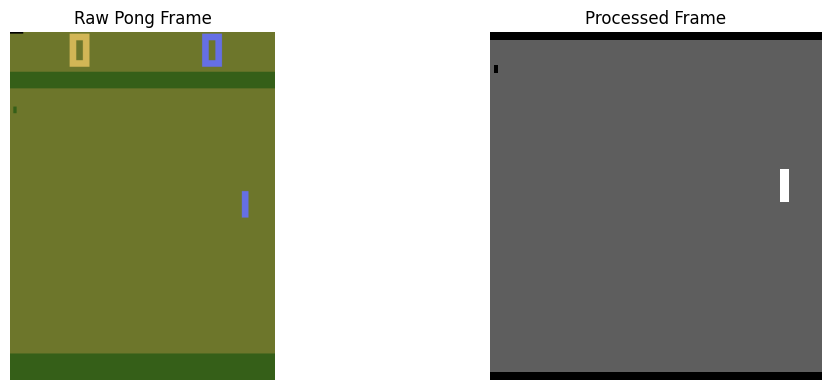

In [27]:
# Recreate the environment to get a sample frame
env = gym.make(ENV_NAME, **ENV_KWARGS)
obs, info = env.reset(seed=SEED)

# Process the raw frame using the provided helper function
processed = utils.process_frame(obs, STATE_SHAPE)

print("Raw frame shape:", obs.shape)
print("Processed frame shape:", processed.shape)

# Display raw and processed images
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(obs)
plt.title("Raw Pong Frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed[0, :, :, 0], cmap="gray")
plt.title("Processed Frame")
plt.axis("off")

plt.tight_layout()
plt.show()

env.close()

### **Interpretation**

**State Preprocessing**

A sample frame from the Pong environment is processed to prepare it for input into the DQN model.

**Processing Steps**

The raw frame undergoes the following transformations:
- Converted from RGB to grayscale  
- Resized from (210, 160) → (84, 80)  
- Normalized and reshaped for model input  

**Shape Comparison**

- Raw frame: (210, 160, 3)  
- Processed frame: (1, 84, 80, 1)  

This reduces input size and removes unnecessary color information while preserving key features such as paddles and ball position.

**Importance**

Preprocessing is essential because:
- Reduces computational complexity  
- Improves training efficiency  
- Helps the model focus on relevant game features  

**Verification**

Raw frame shape: (210, 160, 3)
Processed frame shape: (1, 84, 80, 1)


This confirms that preprocessing is correctly applied and the state is ready for stacking and model input.

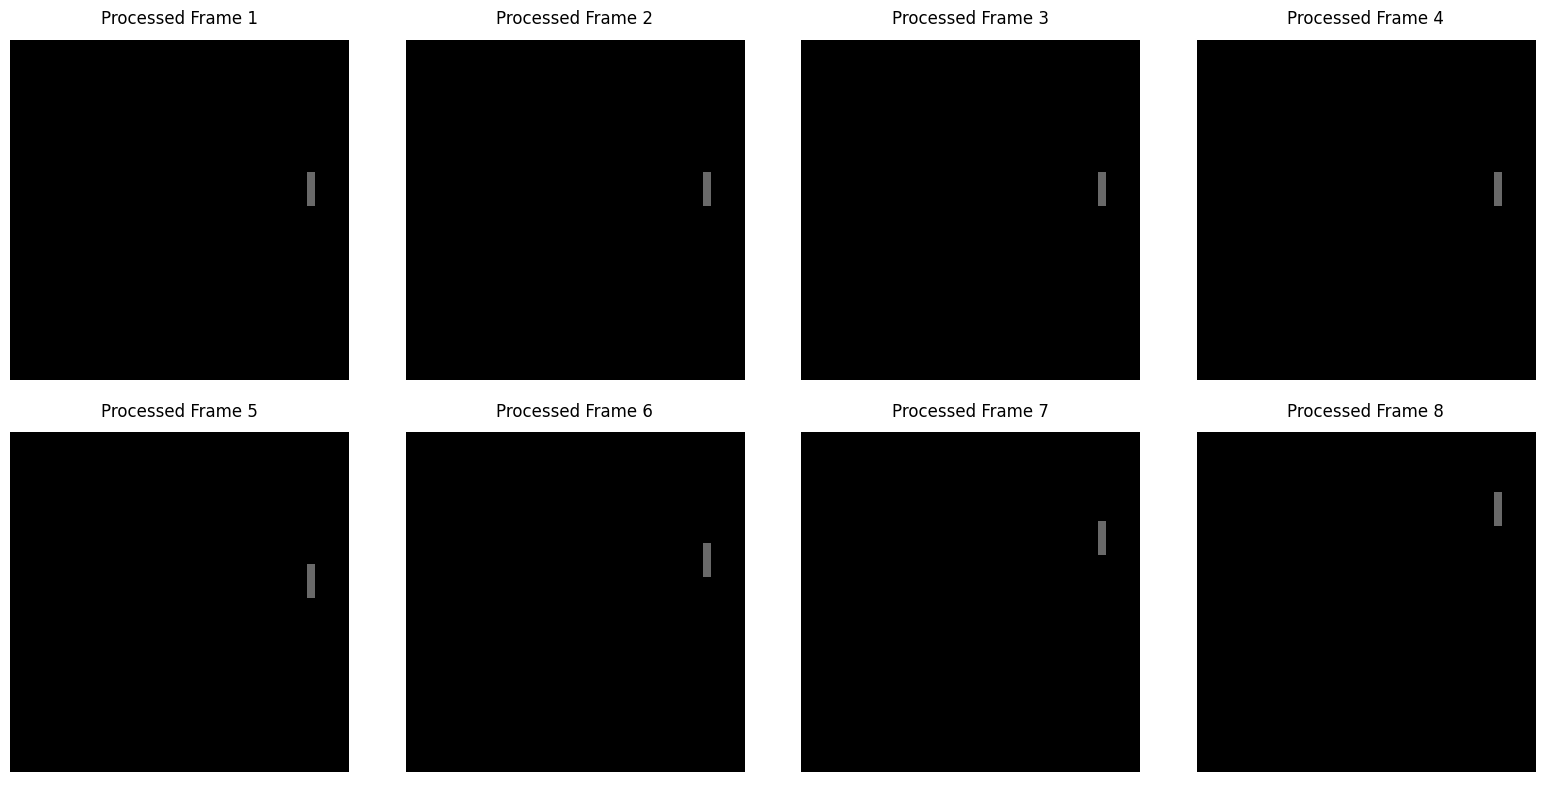

In [28]:
# Visualize several consecutive processed frames after starting gameplay
# using contrast scaling for better human interpretation only

env = gym.make(ENV_NAME, **ENV_KWARGS)
obs, info = env.reset(seed=SEED)

frames = []

# Start the Pong rally with FIRE
fire_action = 1
obs, reward, terminated, truncated, info = env.step(fire_action)

for _ in range(8):
    # Process the current frame using the training pipeline
    processed = utils.process_frame(obs, STATE_SHAPE)
    frames.append(processed[0, :, :, 0])

    # Use a random action after the serve
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    # If episode ends, reset and serve again
    if terminated or truncated:
        obs, info = env.reset()
        obs, reward, terminated, truncated, info = env.step(fire_action)

env.close()

# Plot processed frames with visualization-only contrast enhancement
plt.figure(figsize=(16, 8))
for i, frame in enumerate(frames):
    plt.subplot(2, 4, i + 1)

    # Contrast scaling only for display; does not affect training data
    plt.imshow(frame, cmap="gray", vmin=-0.2, vmax=0.2)

    plt.title(f"Processed Frame {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Interpretation**

**Temporal Frame Visualization**

To understand how the agent perceives motion, multiple consecutive processed frames are visualized after gameplay begins.

**Key Observations**

- Each frame shows the paddle and ball in slightly different positions  
- Changes across frames capture movement over time
- Background remains mostly static, while key objects (paddle/ball) shift  

**Importance of Frame Sequences**

A single frame does not provide motion information. By observing consecutive frames:

- The agent can infer direction and speed of the ball
- Temporal changes help in making better action decisions  
- This justifies the use of frame stacking (STACK_SIZE = 4)

**Visualization Note**

Contrast scaling (vmin, vmax) is applied only for display purposes to make objects more visible.

- This does not affect training data  
- The model still receives the original processed frames  

**Conclusion**

These visualizations confirm that:
- preprocessing preserves important features  
- temporal differences between frames exist  
- the environment provides sufficient information for learning dynamic behavior  

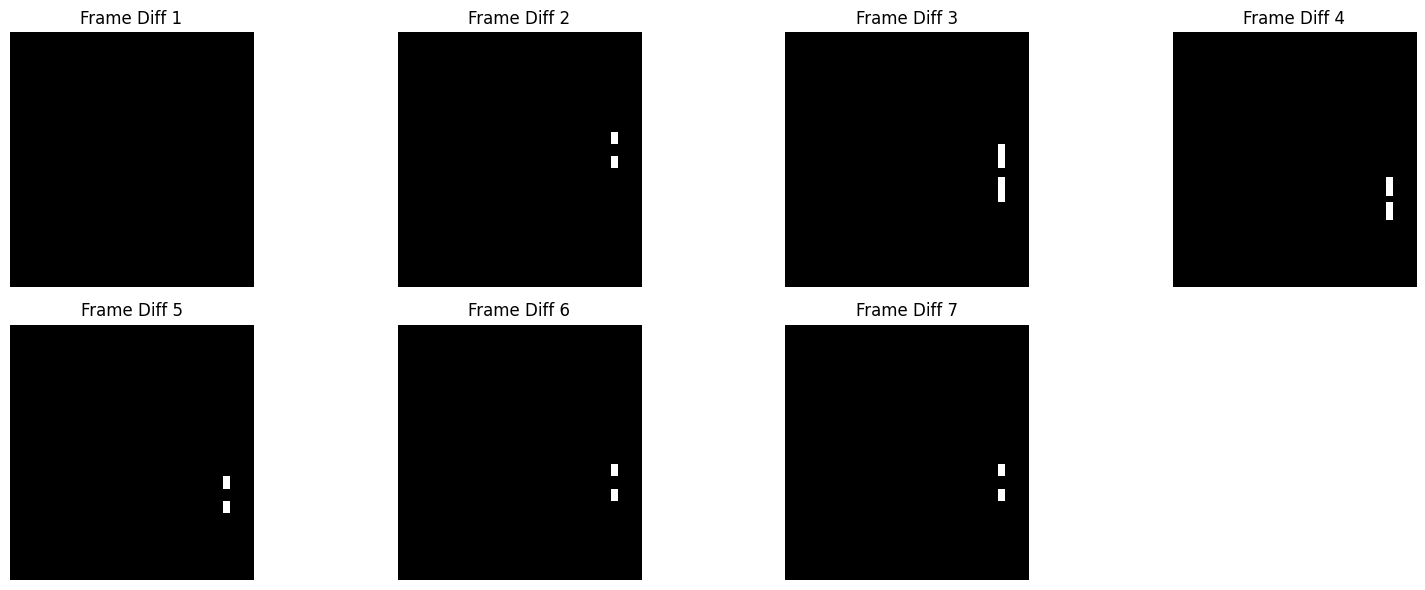

In [29]:
# Visualize motion between consecutive processed frames
env = gym.make(ENV_NAME, **ENV_KWARGS)
obs, info = env.reset(seed=SEED)

frames = []

# Start gameplay with FIRE
fire_action = 1
obs, reward, terminated, truncated, info = env.step(fire_action)

for _ in range(8):
    processed = utils.process_frame(obs, STATE_SHAPE)
    frames.append(processed[0, :, :, 0])

    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        obs, info = env.reset()
        obs, reward, terminated, truncated, info = env.step(fire_action)

env.close()

# Compute absolute differences between consecutive frames
diffs = []
for i in range(len(frames) - 1):
    diffs.append(np.abs(frames[i + 1] - frames[i]))

plt.figure(figsize=(16, 6))
for i, diff in enumerate(diffs):
    plt.subplot(2, 4, i + 1)
    plt.imshow(diff, cmap="gray")
    plt.title(f"Frame Diff {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### **Interpretation**

The preprocessing pipeline effectively reduces visual complexity by removing background details while preserving key game elements such as the paddle.

Although the ball is not consistently visible in individual processed frames due to its small size and downsampling, its presence becomes evident when analyzing differences between consecutive frames. The frame difference visualizations clearly highlight regions of change, indicating object motion.

This confirms that temporal information is preserved, even if spatial details appear limited in single frames. Such motion cues are critical in reinforcement learning, as the agent relies on changes over time to infer direction and speed.

These observations justify the use of frame stacking (STACK_SIZE = 4) in Deep Q-Networks, where multiple consecutive frames provide sufficient context for learning dynamic behavior.

Overall, the preprocessing approach successfully balances dimensionality reduction with retention of essential motion information required for effective policy learning.

### **5. Frame Stacking Helper**

The agent uses 4 stacked frames as the state so that motion information can be learned from consecutive observations.

In [30]:
def stack_frames(frame_stack, new_frame, stack_size=STACK_SIZE):
    """
    Stack processed frames along the channel dimension.

    Parameters:
        frame_stack: deque storing recent processed frames
        new_frame: processed frame with shape (84, 80, 1)
        stack_size: number of frames to stack

    Returns:
        stacked_state: shape (84, 80, 4)
        frame_stack: updated deque
    """
    # At the beginning of an episode, duplicate the first frame
    if len(frame_stack) == 0:
        for _ in range(stack_size):
            frame_stack.append(new_frame)
    else:
        frame_stack.append(new_frame)

    # Concatenate frames along the last dimension
    stacked_state = np.concatenate(frame_stack, axis=2)
    return stacked_state, frame_stack

### **Interpretation**

**Frame Stacking**

To capture motion information, multiple consecutive frames are combined into a single state representation.

**How It Works**

- A deque stores the most recent processed frames  
- At the start of an episode, the first frame is duplicated to fill the stack  
- New frames are appended while older ones are removed automatically  

The final state is created by concatenating frames along the channel dimension:
- Single frame: (84, 80, 1)  
- Stacked state: (84, 80, 4)  

**Why Frame Stacking is Important**

A single frame does not provide information about movement. By stacking frames:

- The agent can infer direction and velocity of the ball
- Temporal context improves decision-making  
- The environment becomes closer to a Markov Decision Process (MDP)

**Key Insight**

Frame stacking enables the model to learn from temporal differences across frames, which is essential for dynamic environments like Pong.

Without stacking, the agent would struggle to understand motion and learn an effective policy.

### **6. Replay Buffer**

Experience replay stores transitions and samples random mini-batches for stable training.

In [31]:
# Transition tuple used for replay memory
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    """Replay memory for storing and sampling transitions."""

    def __init__(self, capacity):
        # Maximum number of stored transitions
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # Store one transition
        self.memory.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size):
        # Randomly sample a mini-batch
        batch = random.sample(self.memory, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        # Current number of stored transitions
        return len(self.memory)

### **Interpretation**

**Experience Replay Buffer**

The replay buffer stores past experiences and enables the agent to learn from randomly sampled mini-batches instead of sequential data.

**How It Works**

Each transition is stored as:
- (state, action, reward, next_state, done)

Key operations:
- push() → adds new experiences to memory  
- sample() → randomly selects a mini-batch for training  
- max capacity → older experiences are automatically removed  

**Why Experience Replay is Important**

- Breaks correlation between consecutive samples  
- Improves training stability  
- Increases data efficiency by reusing past experiences  

Random sampling helps the model generalize better instead of overfitting to recent transitions.

**Key Insight**

Without experience replay, training becomes unstable because updates depend on highly correlated sequential data.

By using a replay buffer, the DQN learns from a more diverse and representative distribution of experiences.

### **7. Deep Q-Network**

A convolutional neural network is used because the state is image-based.

In [32]:
class DQN(nn.Module):
    """CNN-based Q-network for Atari Pong."""

    def __init__(self, input_channels=4, num_actions=6):
        super(DQN, self).__init__()

        # Convolutional feature extractor
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)

        # Dynamically compute flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, IMAGE_HEIGHT, IMAGE_WIDTH)
            conv_out = self._forward_conv(dummy)
            self.flattened_size = conv_out.view(1, -1).size(1)

        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def _forward_conv(self, x):
        # Pass input through convolutional layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        return x

    def forward(self, x):
    # Forward pass through the whole network
        x = self._forward_conv(x)
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

### **Interpretation**

**Deep Q-Network (DQN)**

A Convolutional Neural Network (CNN) is used to approximate the Q-value function since the input state consists of image data.

**Network Architecture**

The model consists of two main components:

**Convolutional Layers**
- Extract spatial features from stacked frames  
- Capture important patterns such as paddle position and ball movement  

Layers:
- Conv1 → 32 filters (8×8, stride 4)  
- Conv2 → 64 filters (4×4, stride 2)  
- Conv3 → 64 filters (3×3, stride 1)  

**Fully Connected Layers**
- Flattened features are passed to dense layers  
- Output represents Q-values for each possible action  

Layers:
- FC1 → 512 units  
- FC2 → number of actions (6)  

**Output**

The network outputs a vector of Q-values:

- Each value corresponds to an action  
- The agent selects the action with the highest Q-value  

**Key Design Choices**

- CNN-based architecture → suitable for image inputs  
- ReLU activation → introduces non-linearity  
- Dynamic flattening → ensures compatibility with input size  

**Key Insight**

The DQN learns to approximate the optimal action-value function:

\[ Q(s, a) \]

By mapping visual input directly to action values, the model enables the agent to learn effective gameplay strategies from raw pixel data.

### **8. DQN Agent**

This class handles action selection, learning, target network synchronization, and epsilon decay.

In [33]:
class DQNAgent:
    """DQN agent with policy network, target network, and epsilon-greedy policy."""

    def __init__(
        self,
        num_actions,
        gamma=GAMMA,
        lr=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        epsilon_start=EPSILON_START,
        epsilon_decay=EPSILON_DECAY,
        epsilon_min=EPSILON_MIN
    ):
        self.num_actions = num_actions
        self.gamma = gamma
        self.batch_size = batch_size

        self.epsilon = epsilon_start
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Online network used for learning
        self.policy_net = DQN(input_channels=STACK_SIZE, num_actions=num_actions).to(DEVICE)

        # Target network used for stable targets
        self.target_net = DQN(input_channels=STACK_SIZE, num_actions=num_actions).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Adam optimizer
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)

    def select_action(self, state):
        """Choose an action using epsilon-greedy exploration."""
        # Random action for exploration
        if random.random() < self.epsilon:
            return random.randrange(self.num_actions)

        # Greedy action from the policy network
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE)
        state_tensor = state_tensor.permute(2, 0, 1).unsqueeze(0)

        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
            action = torch.argmax(q_values, dim=1).item()

        return int(action)

    def decay_epsilon(self):
        """Decay epsilon after each episode."""
        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)

    def train_step(self, replay_buffer):
        """Run one training step using a sampled mini-batch."""
        # Do not train until enough samples exist
        if len(replay_buffer) < self.batch_size:
            return None

        # Sample a mini-batch
        batch = replay_buffer.sample(self.batch_size)

        # Convert batch components to tensors
        states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=DEVICE).permute(0, 3, 1, 2)
        actions = torch.tensor(batch.action, dtype=torch.long, device=DEVICE).unsqueeze(1)
        rewards = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE).unsqueeze(1)
        next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=DEVICE).permute(0, 3, 1, 2)
        dones = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE).unsqueeze(1)

        # Q-values predicted by the policy network
        current_q = self.policy_net(states).gather(1, actions)

        # Stable target values from the target network
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.gamma * max_next_q

        # Mean squared error loss
        loss = F.mse_loss(current_q, target_q)

        # Standard optimization step
        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping for better stability
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)

        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        """Copy policy network weights into target network."""
        self.target_net.load_state_dict(self.policy_net.state_dict())

### **Interpretation**

**DQN Agent**

The DQN agent integrates the policy network, target network, and learning strategy to interact with the environment and update its behavior over time.

**Core Components**

- Policy Network (Online Network)
  Learns and predicts Q-values for the current state  

- Target Network  
  Provides stable target values for training  
  Updated periodically from the policy network  

- Optimizer (Adam) 
  Updates network weights based on loss  

**Action Selection (Epsilon-Greedy)**

The agent balances exploration and exploitation:

- Random action with probability ε (epsilon)  
- Best action (argmax Q-value) otherwise  

Epsilon gradually decays:
- Starts high → encourages exploration  
- Decreases over time → shifts to exploitation  

**Training Process**

During each training step:

1. Sample a mini-batch from the replay buffer  
2. Compute current Q-values using the policy network  
3. Compute target Q-values using the target network  
4. Calculate loss using Mean Squared Error (MSE)  
5. Update network weights via backpropagation  

**Stability Mechanisms**

- Target Network → reduces instability from moving targets  
- Experience Replay → breaks correlation in data  
- Gradient Clipping → prevents exploding gradients  

**Key Insight**

The agent learns by minimizing the difference between predicted and target Q-values, gradually improving its policy through interaction with the environment.

By combining exploration, replay memory, and a target network, the DQN achieves stable and efficient learning in complex environments like Pong.

### **9. Trainer Class**

This class manages:
- environment interaction
- preprocessing
- frame stacking
- replay buffer warmup
- episode training loop
- metrics collection

In [34]:
class PongTrainer:
    """Training manager for DQN on Pong."""

    def __init__(
        self,
        env_name=ENV_NAME,
        env_kwargs=ENV_KWARGS,
        batch_size=BATCH_SIZE,
        target_update_episodes=TARGET_UPDATE_EPISODES,
        num_episodes=NUM_EPISODES_DEBUG
    ):
        self.env_name = env_name
        self.env_kwargs = env_kwargs
        self.batch_size = batch_size
        self.target_update_episodes = target_update_episodes
        self.num_episodes = num_episodes

        # Create the environment
        self.env = gym.make(self.env_name, **self.env_kwargs)
        self.num_actions = self.env.action_space.n

        # Create agent and replay buffer
        self.agent = DQNAgent(num_actions=self.num_actions, batch_size=batch_size)
        self.replay_buffer = ReplayBuffer(MEMORY_SIZE)

        # Training metrics
        self.episode_scores = []
        self.last5_avg_rewards = []
        self.loss_history = []
        self.episode_steps = []

    def preprocess_observation(self, obs):
        """Convert raw RGB frame into processed frame with shape (84, 80, 1)."""
        return utils.process_frame(obs, STATE_SHAPE)[0]

    def initialize_state(self, obs):
        """Build the initial stacked state at the start of an episode."""
        frame_stack = deque(maxlen=STACK_SIZE)
        processed_frame = self.preprocess_observation(obs)
        state, frame_stack = stack_frames(frame_stack, processed_frame)
        return state, frame_stack

    def warmup_replay_buffer(self):
        """Fill replay memory with random experience before learning starts."""
        print("Warming up replay buffer...")

        obs, info = self.env.reset(seed=SEED)
        state, frame_stack = self.initialize_state(obs)

        while len(self.replay_buffer) < MIN_REPLAY_SIZE:
            # Random exploratory action
            action = self.env.action_space.sample()

            # Step the environment
            next_obs, reward, terminated, truncated, info = self.env.step(action)
            done = terminated or truncated

            # Transform reward using provided helper
            transformed_reward = utils.transform_reward(reward)

            # Build next stacked state
            next_frame = self.preprocess_observation(next_obs)
            next_state, frame_stack = stack_frames(frame_stack, next_frame)

            # Store the transition
            self.replay_buffer.push(state, action, transformed_reward, next_state, done)

            # Move to the next state
            state = next_state

            # Reset if episode ends during warmup
            if done:
                obs, info = self.env.reset()
                state, frame_stack = self.initialize_state(obs)

        print(f"Replay buffer size after warmup: {len(self.replay_buffer)}")

    def train(self):
        """Run full training."""
        self.warmup_replay_buffer()

        total_steps = 0

        for episode in range(1, self.num_episodes + 1):
            # Reset environment at start of episode
            obs, info = self.env.reset()
            state, frame_stack = self.initialize_state(obs)

            done = False
            episode_reward = 0.0
            step_count = 0

            while not done and step_count < MAX_STEPS_PER_EPISODE:
                # Select epsilon-greedy action
                action = self.agent.select_action(state)

                # Interact with environment
                next_obs, reward, terminated, truncated, info = self.env.step(action)
                done = terminated or truncated

                # Use transformed reward for learning
                transformed_reward = utils.transform_reward(reward)

                # Build next state
                next_frame = self.preprocess_observation(next_obs)
                next_state, frame_stack = stack_frames(frame_stack, next_frame)

                # Store transition
                self.replay_buffer.push(state, action, transformed_reward, next_state, done)

                # Learn every TRAIN_EVERY steps
                if total_steps % TRAIN_EVERY == 0:
                    loss = self.agent.train_step(self.replay_buffer)
                    if loss is not None:
                        self.loss_history.append(loss)

                # Update state
                state = next_state

                # Track original episode reward as score
                episode_reward += reward
                step_count += 1
                total_steps += 1

            # Store assignment metrics
            self.episode_scores.append(episode_reward)
            avg_last5 = np.mean(self.episode_scores[-5:])
            self.last5_avg_rewards.append(avg_last5)
            self.episode_steps.append(total_steps)

            # Update target network according to experiment setting
            if episode % self.target_update_episodes == 0:
                self.agent.update_target_network()

            # Decay epsilon after episode
            self.agent.decay_epsilon()

            print(
                f"Episode {episode:03d} | "
                f"Score: {episode_reward:6.2f} | "
                f"AvgLast5: {avg_last5:6.2f} | "
                f"Epsilon: {self.agent.epsilon:6.4f}"
            )

        self.env.close()

    def get_results(self):
        """Return training results in dictionary form."""
        return {
            "episode_scores": self.episode_scores,
            "last5_avg_rewards": self.last5_avg_rewards,
            "episode_steps": self.episode_steps,
            "loss_history": self.loss_history,
            "batch_size": self.batch_size,
            "target_update_episodes": self.target_update_episodes
        }

### **Interpretation**

**DQN Training Process**

The PongTrainer class manages the full training pipeline, including environment interaction, experience collection, and model updates.

**Training Workflow**

Each episode follows this sequence:

1. Reset environment and initialize stacked state  
2. Select action using epsilon-greedy policy  
3. Execute action and observe next state and reward  
4. Store transition in replay buffer  
5. Sample mini-batch and update the policy network  
6. Repeat until episode ends  

**Replay Buffer Warmup**

Before training begins, the replay buffer is populated using random actions:

- Ensures sufficient data diversity  
- Prevents unstable early training  
- Enables meaningful mini-batch updates  

**Learning Strategy**

- **Reward Transformation** → stabilizes learning signal  
- **Training Frequency** → updates occur every step  
- **Mini-batch Learning** → improves generalization  

The agent learns by minimizing the difference between predicted and target Q-values.

**Stability Techniques**

- **Target Network Updates** → performed every fixed number of episodes  
- **Epsilon Decay** → gradually reduces exploration  
- **Step Limit per Episode** → avoids excessively long episodes  

**Metrics Tracked**

- Episode rewards (scores)  
- Average reward over last 5 episodes  
- Training loss  
- Total steps  

These metrics are used to evaluate learning progress and performance.

**Key Insight**

The training loop integrates all core DQN components—exploration, replay memory, and target networks—into a stable learning process.

By iteratively improving Q-value estimates through interaction with the environment, the agent gradually learns an effective policy for playing Pong.

### **10. Plotting Utilities**

These functions are used to visualize the required assignment results.

In [35]:
def plot_training_metrics(results, title_suffix="Run"):
    """Plot score per episode and average reward of the last 5 episodes."""
    scores = results["episode_scores"]
    avg_last5 = results["last5_avg_rewards"]
    steps = results["episode_steps"]

    plt.figure(figsize=(12, 5))
    plt.plot(steps, scores)
    plt.title(f"Score per Episode - {title_suffix}")
    plt.xlabel("Training Steps")
    plt.ylabel("Episode Score")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(steps, avg_last5)
    plt.title(f"Average Cumulative Reward of Last 5 Episodes - {title_suffix}")
    plt.xlabel("Training Steps")
    plt.ylabel("Average Reward")
    plt.grid(True)
    plt.show()


def compare_runs(results_list, metric_key, labels, title, ylabel):
    """Compare a selected metric across multiple runs."""
    plt.figure(figsize=(12, 5))

    for results, label in zip(results_list, labels):
        x = results["episode_steps"]
        y = results[metric_key]
        plt.plot(x, y, label=label)

    plt.title(title)
    plt.xlabel("Training Steps")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

### **Interpretation**

**Training Visualization**

These functions are used to visualize the agent’s learning progress and compare different experimental runs.

**Metrics Plotted**

- Score per Episode 
  Shows the reward obtained in each episode over training  

- Average Reward (Last 5 Episodes) 
  Smooths performance to highlight overall learning trends  

**Comparison Across Runs**

The compare_runs function allows multiple experiments to be plotted together:

- Enables evaluation of different hyperparameters  
- Helps identify which configuration performs better  
- Supports experimental analysis and reporting  

**Importance**

Visualization is essential for:

- Understanding learning behavior over time  
- Detecting instability or convergence issues  
- Comparing performance across experiments  

**Key Insight**

By analyzing both raw scores and smoothed averages, we can better assess whether the agent is improving consistently and learning an effective policy.

### **11. Default Training Run**

This first run uses the assignment default settings:
- batch size = 8
- target update = every 10 episodes
- gamma = 0.95
- epsilon start = 1.0
- epsilon decay = 0.995
- epsilon minimum = 0.05

In [36]:
# For first testing, use NUM_EPISODES_DEBUG
default_trainer = PongTrainer(
    batch_size=8,
    target_update_episodes=10,
    num_episodes=NUM_EPISODES_DEBUG
)

default_trainer.train()
default_results = default_trainer.get_results()

Warming up replay buffer...
Replay buffer size after warmup: 1000
Episode 001 | Score: -20.00 | AvgLast5: -20.00 | Epsilon: 0.9950
Episode 002 | Score: -19.00 | AvgLast5: -19.50 | Epsilon: 0.9900
Episode 003 | Score: -21.00 | AvgLast5: -20.00 | Epsilon: 0.9851
Episode 004 | Score: -19.00 | AvgLast5: -19.75 | Epsilon: 0.9801
Episode 005 | Score: -19.00 | AvgLast5: -19.60 | Epsilon: 0.9752


### **Interpretation**

**Initial Debug Run**

A short training run is executed using a small number of episodes (NUM_EPISODES_DEBUG = 5) to verify that the implementation works correctly.

**Observations**

- Replay buffer is successfully warmed up to the required size  
- Training loop runs without errors  
- Episode scores are consistently negative (expected in early training)  
- Epsilon decreases gradually, indicating proper exploration decay  

**Performance Insight**

The agent performs poorly during initial episodes because:
- It is still exploring randomly  
- The policy network is not yet trained  
- Pong is a challenging environment with sparse rewards  

**Purpose of Debug Run**

- Validate correctness of the full training pipeline  
- Ensure replay buffer, agent, and environment interaction work properly  
- Confirm that learning signals (loss, rewards, epsilon decay) behave as expected  

**Conclusion**

The debug run confirms that the system is functioning correctly and is ready for longer training experiments with increased episodes.

In [37]:
print(default_results.keys())

dict_keys(['episode_scores', 'last5_avg_rewards', 'episode_steps', 'loss_history', 'batch_size', 'target_update_episodes'])


### **Training Results Structure**

The training output is stored in a structured dictionary containing key metrics collected during learning.

**Available Metrics**

- **episode_scores** → reward obtained per episode  
- **last5_avg_rewards** → average reward over the last 5 episodes  
- **episode_steps** → cumulative training steps  
- **loss_history** → training loss values over time  
- **batch_size** → mini-batch size used  
- **target_update_episodes** → frequency of target network updates  

**Purpose**

This structured format allows:

- Easy visualization of training progress  
- Comparison across different experiments  
- Analysis of learning behavior and stability  

**Key Insight**

By organizing results into well-defined metrics, we can systematically evaluate performance, identify trends, and support data-driven conclusions in reinforcement learning experiments.

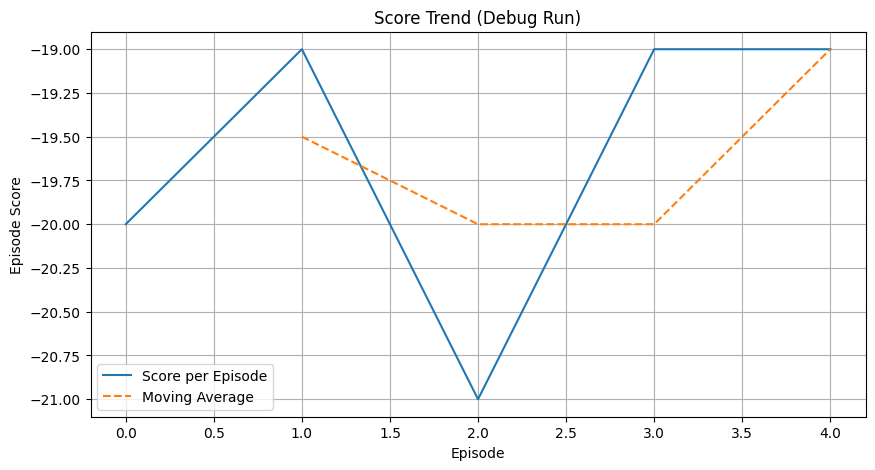

In [38]:
plt.figure(figsize=(10, 5))

scores = default_results["episode_scores"]

plt.plot(scores, label="Score per Episode")

window = 2
if len(scores) >= window:
    moving_avg = np.convolve(
        scores,
        np.ones(window) / window,
        mode="valid"
    )
    plt.plot(
        range(window - 1, len(scores)),
        moving_avg,
        label="Moving Average",
        linestyle="--"
    )

plt.title("Score Trend (Debug Run)")
plt.xlabel("Episode")
plt.ylabel("Episode Score")
plt.legend()
plt.grid(True)
plt.show()

### **Score Trend Analysis (Debug Run)**

The plot shows the episode scores along with a moving average to observe short-term performance trends.

**Observations**

- Scores remain consistently negative across episodes  
- Small fluctuations indicate unstable early learning  
- The moving average smooths variations but shows no clear improvement trend  

**Interpretation**

This behavior is expected during initial training because:
- The agent is still exploring randomly (high epsilon)  
- The policy network has not yet learned meaningful patterns  
- Pong provides sparse rewards, making early progress difficult  

**Role of Moving Average**

- Helps reduce noise in individual episode scores  
- Provides a clearer view of overall learning direction  
- Useful for identifying convergence in longer runs  

**Conclusion**

The debug run confirms that learning has not yet stabilized, which is expected at this stage. Longer training with more episodes is required for the agent to improve performance.

### **12. Plot Default Training Results**

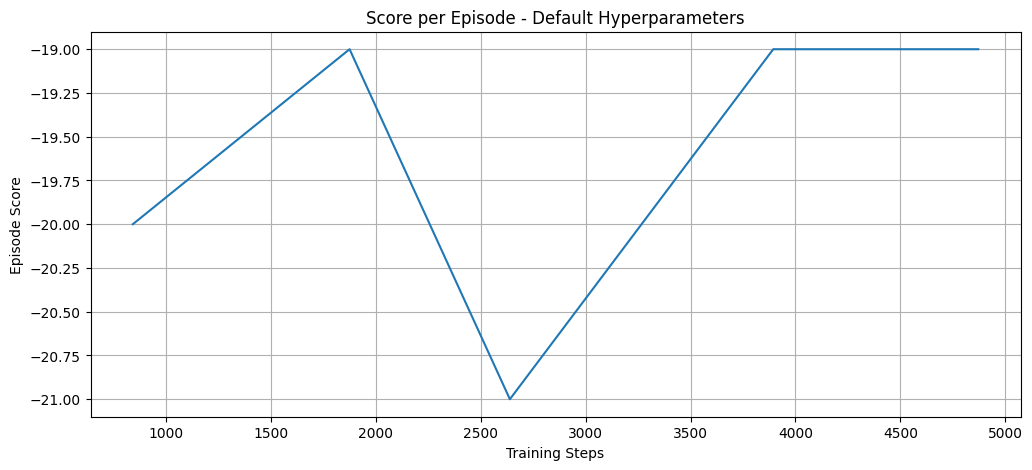

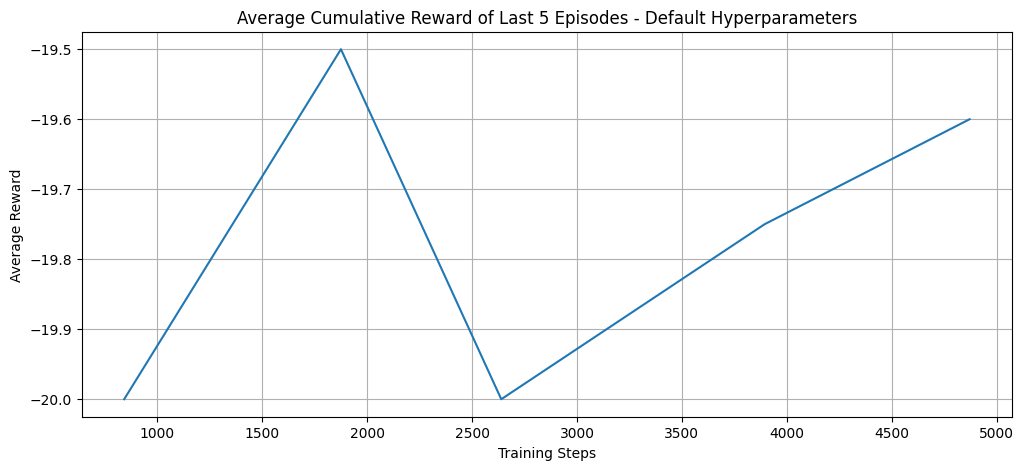

In [39]:
plot_training_metrics(default_results, title_suffix="Default Hyperparameters")

### **Default Training Results**

The plots show the agent’s performance using the default hyperparameters over the debug training run.

**Observations**

- Episode scores remain in a narrow negative range (≈ -21 to -19)  
- No clear upward trend is observed in the short run  
- The average reward over the last 5 episodes remains relatively stable  

**Interpretation**

These results indicate that the agent has not yet learned an effective policy. This is expected because:

- The number of episodes is very small (debug setting)  
- Exploration is still high (epsilon close to 1)  
- Pong requires longer training to observe meaningful improvement  

**Learning Behavior**

- Slight fluctuations suggest the agent is interacting correctly with the environment  
- Stable averages indicate no divergence or instability  
- No convergence is observed due to insufficient training duration  

**Key Insight**

The default debug run validates that:
- The training pipeline is functioning correctly  
- Metrics are being tracked and plotted properly  
- The agent is ready for extended training experiments  

**Conclusion**

While no learning improvement is visible at this stage, the results confirm that the implementation is correct and suitable for scaling to longer training runs where meaningful performance gains can be observed.

### **12A. Why This Comparison Was Added**

The initial 5-episode run was used as a short debug experiment to verify that the training pipeline, replay buffer, model, and plotting logic were functioning correctly.

After confirming that the implementation worked, additional runs with 250 and 500 episodes were performed to study how increasing training duration affects reward trends and learning behavior.

This comparison helps distinguish between debug-stage execution and more meaningful training runs.

### **12B. Training Duration Comparison**

In addition to the required assignment experiments, a training-duration comparison was performed using the default configuration for:
- 5 episodes
- 250 episodes
- 500 episodes

This comparison helps show how increasing the number of training episodes affects the agent’s learning behavior.

In [40]:
# Longer training durations are introduced only after the debug run
NUM_EPISODES_COMPARE = 250
NUM_EPISODES_LONG = 500

### **Extended Training Setup**

After validating the implementation using a short debug run, longer training durations are introduced for meaningful learning.

**Configuration**

- **NUM_EPISODES_COMPARE = 250** → intermediate training duration  
- **NUM_EPISODES_LONG = 500** → extended training for deeper learning  

**Purpose**

- Move from validation → actual learning  
- Observe performance trends over longer horizons  
- Enable comparison between different training durations  

**Expected Outcome**

With increased episodes:
- Exploration decreases (epsilon decay)  
- The agent begins to learn useful strategies  
- Performance trends (improvement or convergence) become visible  

**Key Insight**

Short runs validate correctness, but longer runs are essential to evaluate learning effectiveness in reinforcement learning tasks like Pong.

In [41]:
def run_duration_experiment(num_episodes):
    """Run one training experiment for a specified number of episodes."""
    trainer = PongTrainer(
        batch_size=8,
        target_update_episodes=10,
        num_episodes=num_episodes
    )
    trainer.train()
    return trainer.get_results()

### **Duration Experiment Function**

This function runs a complete training experiment for a specified number of episodes.

**How It Works**

- Initializes a new PongTrainer instance  
- Sets the desired number of training episodes  
- Executes training  
- Returns structured results for analysis  

**Purpose**

- Enables controlled comparison of different training durations  
- Supports experimentation without modifying core training logic  
- Ensures consistency across runs (same hyperparameters, different episode counts)  

**Usage**

This function is used to run experiments such as:
- 250 episodes (moderate training)  
- 500 episodes (extended training)  

Results from each run can then be compared using visualization functions.

**Key Insight**

Encapsulating experiments into a reusable function improves modularity, reproducibility, and clarity when evaluating the impact of training duration on performance.

In [42]:
# Reuse the existing 5-episode default run to avoid redundant computation
results_ep5 = default_results
results_ep250 = run_duration_experiment(250)
results_ep500 = run_duration_experiment(500)

Warming up replay buffer...
Replay buffer size after warmup: 1000
Episode 001 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9950
Episode 002 | Score: -20.00 | AvgLast5: -20.50 | Epsilon: 0.9900
Episode 003 | Score: -21.00 | AvgLast5: -20.67 | Epsilon: 0.9851
Episode 004 | Score: -20.00 | AvgLast5: -20.50 | Epsilon: 0.9801
Episode 005 | Score: -20.00 | AvgLast5: -20.40 | Epsilon: 0.9752
Episode 006 | Score: -21.00 | AvgLast5: -20.40 | Epsilon: 0.9704
Episode 007 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9655
Episode 008 | Score: -20.00 | AvgLast5: -20.40 | Epsilon: 0.9607
Episode 009 | Score: -20.00 | AvgLast5: -20.40 | Epsilon: 0.9559
Episode 010 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9511
Episode 011 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9464
Episode 012 | Score: -20.00 | AvgLast5: -20.40 | Epsilon: 0.9416
Episode 013 | Score: -20.00 | AvgLast5: -20.40 | Epsilon: 0.9369
Episode 014 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9322
Episode 015 | Score: -21

### **Understanding Rewards in Pong**

In Atari Pong, episode rewards typically range from -21 to +21, where:
- -21 indicates a complete loss  
- +21 indicates a complete win  

Higher values therefore represent better agent performance.

This context is important when interpreting the training plots below.

### **Multi-Duration Training Runs**

This step runs the main duration experiments for 5, 250, and 500 episodes.

To avoid unnecessary computation, the previously completed 5-episode debug run is reused, while new experiments are executed for 250 and 500 episodes.

**Purpose**

The goal is to compare how training duration affects learning performance:

- **5 episodes** → implementation check only  
- **250 episodes** → intermediate learning behavior  
- **500 episodes** → longer training for stronger policy improvement  

**Observations from Console Output**

The printed logs show that:

- the replay buffer is successfully warmed up before each run  
- epsilon decays gradually across episodes  
- scores remain poor early in training, then improve over longer runs  
- the 250-episode run begins to show moderate improvement  
- the 500-episode run shows much stronger learning, including several positive scores  

**Interpretation**

These results suggest that the agent requires substantial interaction with the environment before meaningful learning appears.

In the shorter and medium runs, performance is still limited because:
- exploration remains relatively high  
- the agent is still learning basic control behavior  
- Pong is a sparse-reward environment  

By the 500-episode run, the agent starts achieving positive rewards, indicating that it is learning strategies that outperform random behavior.

**Conclusion**

This experiment confirms that training duration has a major impact on DQN performance.

The 5-episode run is useful only for debugging, the 250-episode run shows partial learning, and the 500-episode run provides clear evidence of more effective policy learning.

In [43]:
def plot_duration_comparison(results_dict, metric_key="episode_scores", window=10):
    """Compare score trends across different training durations."""
    plt.figure(figsize=(12, 6))

    for label, results in results_dict.items():
        values = results[metric_key]
        episodes = np.arange(1, len(values) + 1)

        # Plot raw score curve
        plt.plot(episodes, values, alpha=0.3, label=f"{label} (raw)")

        # Plot moving average when enough points are available
        if len(values) >= window:
            moving_avg = np.convolve(values, np.ones(window) / window, mode="valid")
            plt.plot(
                np.arange(window, len(values) + 1),
                moving_avg,
                linewidth=2,
                label=f"{label} (moving avg)"
            )

    plt.title("Score Trend by Training Duration")
    plt.xlabel("Episode")
    plt.ylabel("Episode Score")
    plt.legend()
    plt.grid(True)
    plt.show()

### **Duration Comparison Plot**

This function compares score trends across training runs with different episode lengths.

**How It Works**

For each experiment:
- the raw episode scores are plotted with transparency  
- a moving average is added when enough episodes are available  

This makes it easier to compare both:
- short-term variability  
- overall performance trends  

**Purpose**

The comparison plot is used to evaluate how learning changes as training duration increases.

It helps answer whether:
- longer training improves performance  
- score trends become more stable  
- the agent shows evidence of convergence  

**Why Moving Average is Useful**

Raw reinforcement learning scores can be noisy.  
The moving average helps reveal the underlying learning trend more clearly by smoothing short-term fluctuations.

***Key Insight***

This visualization supports direct comparison between the 5-, 250-, and 500-episode experiments, making it easier to assess the effect of training duration on DQN performance.

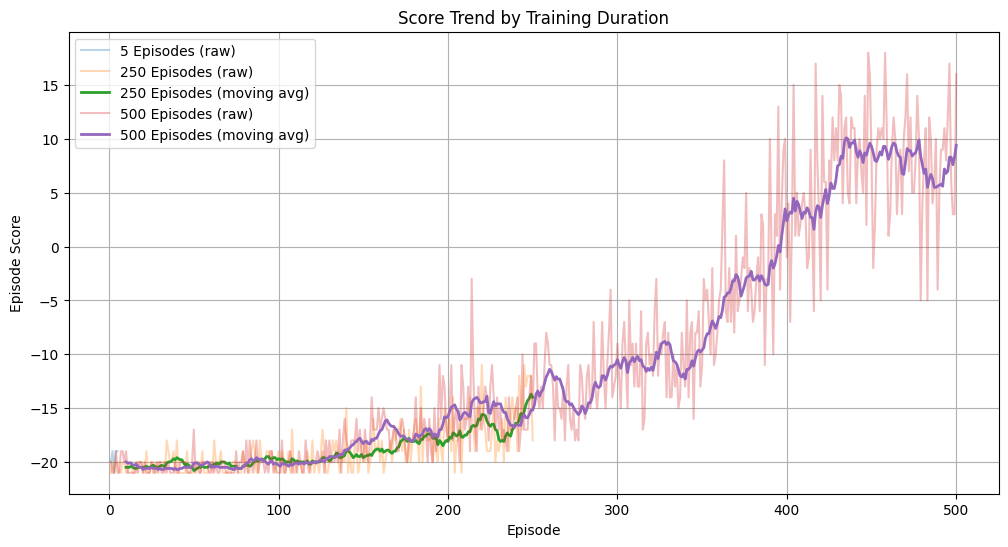

In [44]:
duration_results = {
    "5 Episodes": results_ep5,
    "250 Episodes": results_ep250,
    "500 Episodes": results_ep500
}

plot_duration_comparison(duration_results, metric_key="episode_scores", window=10)

### **Training Duration Comparison Results**

The plot compares score trends across 5, 250, and 500 episode training runs using both raw scores and moving averages.

**Observations**

- *5 episodes*:
  - Scores remain consistently low (~ -20)
  - No learning is observed (debug run only)

- *250 episodes*:
  - Gradual improvement begins after ~150–200 episodes
  - Scores remain mostly negative but show upward trend
  - Learning is present but not yet stable

- *500 episodes*:
  - Clear upward trend after ~300 episodes
  - Scores transition from negative to positive values
  - Higher variability but significantly better performance

**Interpretation**

- The agent requires a large number of episodes before meaningful learning occurs  
- Early training is dominated by exploration and poor performance  
- Longer training allows the agent to:
  - refine action-value estimates  
  - reduce randomness  
  - learn effective gameplay strategies  

The moving average highlights a clear learning curve, especially in the 500-episode run.

**Conclusion**

Training duration has a strong impact on DQN performance:

- Short runs (5 episodes) are insufficient for learning  
- Medium runs (250 episodes) show partial improvement  
- Longer runs (500 episodes) enable effective learning and positive rewards  

This confirms that extended training is essential for convergence in reinforcement learning tasks like Pong.

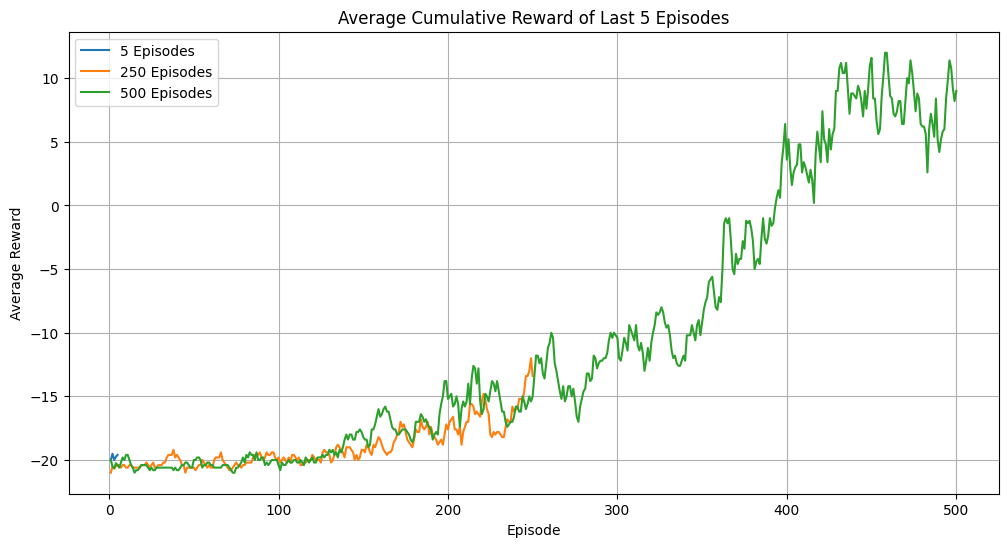

In [45]:
def plot_duration_avg5(results_dict):
    """Compare average cumulative reward of the last 5 episodes across training durations."""
    plt.figure(figsize=(12, 6))

    for label, results in results_dict.items():
        values = results["last5_avg_rewards"]
        episodes = np.arange(1, len(values) + 1)
        plt.plot(episodes, values, label=label)

    plt.title("Average Cumulative Reward of Last 5 Episodes")
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_duration_avg5(duration_results)

#### **Interpretation**

The 5-episode run serves as a debug baseline and remains consistently near -20, showing no learning due to insufficient experience.

The 250-episode run shows gradual improvement, with the average reward slowly increasing but still remaining mostly negative. This indicates early-stage learning, but the agent has not yet developed a strong policy.

The 500-episode run demonstrates clear learning progression. After around 300–350 episodes, the average reward increases significantly, eventually reaching positive values. This indicates that the agent is learning effective strategies and improving performance over time.

Overall, the results confirm that training duration has a major impact on reinforcement learning performance. Short runs are useful for debugging, while longer runs are necessary to observe meaningful learning and policy improvement.

### **13. Experiment 1 - Batch Size Comparison**

This experiment compares:
- batch size 8
- batch size 16

In [46]:
# Batch size 8
trainer_bs8 = PongTrainer(
    batch_size=8,
    target_update_episodes=10,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_bs8.train()
results_bs8 = trainer_bs8.get_results()

# Batch size 16
trainer_bs16 = PongTrainer(
    batch_size=16,
    target_update_episodes=10,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_bs16.train()
results_bs16 = trainer_bs16.get_results()

Warming up replay buffer...
Replay buffer size after warmup: 1000
Episode 001 | Score: -19.00 | AvgLast5: -19.00 | Epsilon: 0.9950
Episode 002 | Score: -21.00 | AvgLast5: -20.00 | Epsilon: 0.9900
Episode 003 | Score: -20.00 | AvgLast5: -20.00 | Epsilon: 0.9851
Episode 004 | Score: -21.00 | AvgLast5: -20.25 | Epsilon: 0.9801
Episode 005 | Score: -21.00 | AvgLast5: -20.40 | Epsilon: 0.9752
Episode 006 | Score: -19.00 | AvgLast5: -20.40 | Epsilon: 0.9704
Episode 007 | Score: -21.00 | AvgLast5: -20.40 | Epsilon: 0.9655
Episode 008 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9607
Episode 009 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9559
Episode 010 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9511
Episode 011 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9464
Episode 012 | Score: -20.00 | AvgLast5: -20.80 | Epsilon: 0.9416
Episode 013 | Score: -20.00 | AvgLast5: -20.60 | Epsilon: 0.9369
Episode 014 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9322
Episode 015 | Score: -18

### **Experiment 1: Batch Size Comparison**

This experiment compares the effect of two batch sizes:

- Batch size = 8
- Batch size = 16

Both runs use the same training duration (250 episodes) and the same target network update setting, so the main difference is the mini-batch size used during learning.

**Observations from Console Output**

For both runs:

- the replay buffer is warmed up successfully before training starts  
- epsilon decays gradually in the same way across episodes  
- scores remain mostly negative throughout training  
- neither configuration reaches strong or stable positive performance within 250 episodes  

However, some differences can still be observed:

- Batch size 8 shows slightly earlier and somewhat stronger improvement in some parts of training  
- Batch size 16 appears more conservative, with learning remaining slower and performance staying more consistently negative  

**Interpretation**

The batch size affects how many replay samples are used in each update step.

- A smaller batch size (8) can lead to more frequent and noisier gradient updates, which may help the agent adapt faster early in training
- A larger batch size (16) provides more averaged updates, which may be more stable but can slow down learning in shorter runs

In this experiment, batch size 8 appears slightly better suited to the 250-episode training budget, as it shows somewhat better progress by the end of training.

**Conclusion**

This experiment suggests that *batch size influences learning speed and training behavior*.

Under the current setup:

- Batch size 8 appears to perform slightly better
- Batch size 16 does not show a clear advantage within 250 episodes

This indicates that for shorter training budgets, a smaller batch size may help the DQN learn more effectively.

In [47]:
# Target update every 3 episodes
trainer_tu3 = PongTrainer(
    batch_size=8,
    target_update_episodes=3,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_tu3.train()
results_tu3 = trainer_tu3.get_results()

# Target update every 10 episodes
trainer_tu10 = PongTrainer(
    batch_size=8,
    target_update_episodes=10,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_tu10.train()
results_tu10 = trainer_tu10.get_results()

Warming up replay buffer...
Replay buffer size after warmup: 1000
Episode 001 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9950
Episode 002 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9900
Episode 003 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9851
Episode 004 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9801
Episode 005 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9752
Episode 006 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9704
Episode 007 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9655
Episode 008 | Score: -20.00 | AvgLast5: -20.80 | Epsilon: 0.9607
Episode 009 | Score: -21.00 | AvgLast5: -20.80 | Epsilon: 0.9559
Episode 010 | Score: -21.00 | AvgLast5: -20.80 | Epsilon: 0.9511
Episode 011 | Score: -21.00 | AvgLast5: -20.80 | Epsilon: 0.9464
Episode 012 | Score: -21.00 | AvgLast5: -20.80 | Epsilon: 0.9416
Episode 013 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9369
Episode 014 | Score: -20.00 | AvgLast5: -20.80 | Epsilon: 0.9322
Episode 015 | Score: -20

### **Experiment 2: Target Network Update Frequency**

This experiment compares two target network update settings:

- Update every 3 episodes
- Update every 10 episodes

Both runs use the same batch size (8) and the same training duration (250 episodes), so the main difference is how often the target network is synchronized with the policy network.

**Observations from Console Output**

For both runs:

- the replay buffer is warmed up correctly before training  
- epsilon decays in the same way across episodes  
- scores remain mostly negative for much of training  
- neither configuration achieves strong positive performance within 250 episodes  

Some differences are visible:

- Update every 3 episodes shows earlier improvement in some parts of training and reaches slightly better scores near the end  
- Update every 10 episodes appears slower and more conservative, with weaker late-stage improvement  

**Interpretation**

The target network helps stabilize DQN learning by providing fixed Q-targets for a period of time.

- More frequent updates (every 3 episodes) allow the target values to reflect the latest learned policy more quickly
- Less frequent updates (every 10 episodes) provide more stable targets, but adaptation may be slower

In this experiment, updating the target network every 3 episodes appears slightly more effective under the 250-episode budget, likely because the agent benefits from faster propagation of improved value estimates.

**Conclusion**

This comparison suggests that target update frequency influences learning speed and training behavior.

Under the current setup:

- Target update every 3 episodes performs slightly better
- Target update every 10 episodes does not show a clear advantage in this shorter run

This indicates that with limited training duration, more frequent target synchronization may help the DQN improve faster.

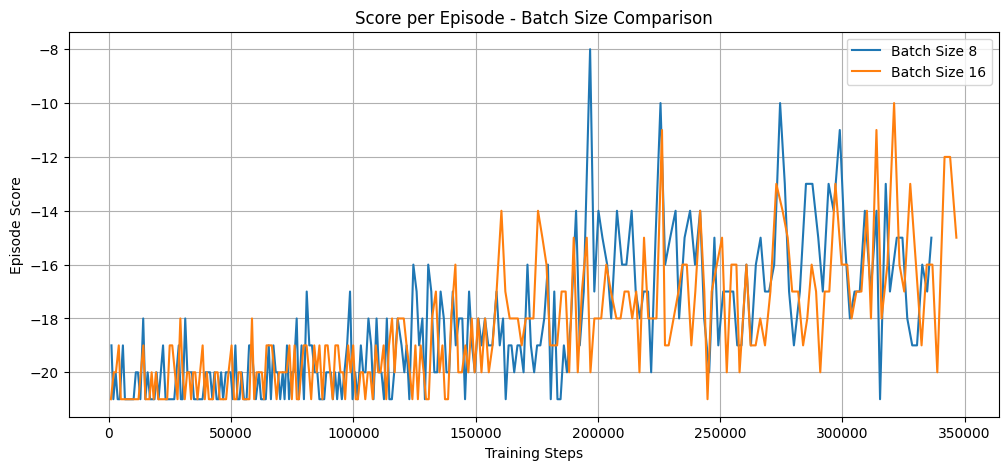

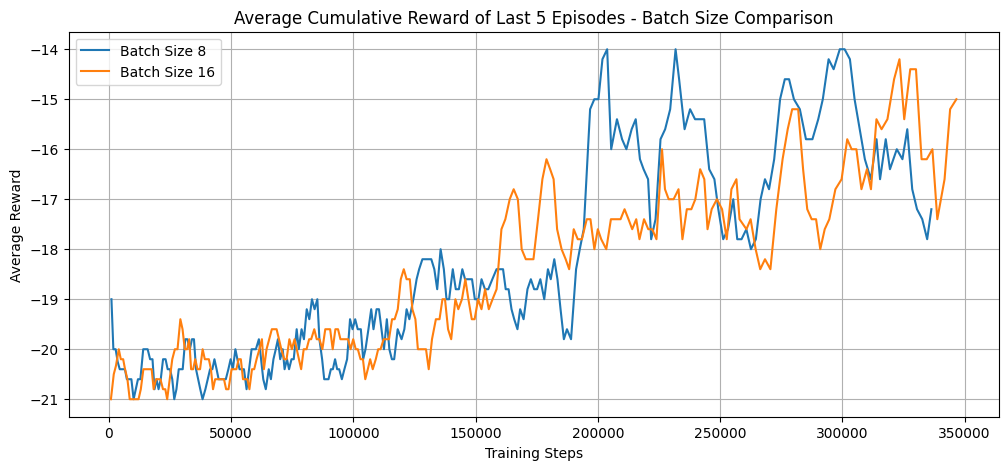

In [48]:
compare_runs(
    results_list=[results_bs8, results_bs16],
    metric_key="episode_scores",
    labels=["Batch Size 8", "Batch Size 16"],
    title="Score per Episode - Batch Size Comparison",
    ylabel="Episode Score"
)

compare_runs(
    results_list=[results_bs8, results_bs16],
    metric_key="last5_avg_rewards",
    labels=["Batch Size 8", "Batch Size 16"],
    title="Average Cumulative Reward of Last 5 Episodes - Batch Size Comparison",
    ylabel="Average Reward"
)

#### **Interpretation**

Both batch size settings show gradual improvement over training, but neither produces a consistently dominant advantage across the full run.

From the score per episode plot, both configurations remain noisy, which is expected in reinforcement learning. Batch size 8 shows a few stronger short-term improvements, but also more fluctuation. Batch size 16 appears slightly smoother in some regions, though it does not clearly outperform batch size 8.

From the average cumulative reward of the last 5 episodes plot, both runs improve from around -20 toward approximately -15 to -14 by the end of training. Batch size 8 reaches slightly better average rewards in some middle portions of training, while batch size 16 becomes competitive later in the run.

Overall, the comparison suggests that both batch sizes support learning, but the difference between them is modest under the current 250-episode setting. Batch size 8 may allow slightly faster short-term adaptation, while batch size 16 may provide somewhat smoother updates. A longer training duration would be needed to determine whether one batch size is consistently superior.

### **14. Experiment 2 - Target Update Comparison**

This experiment compares:
- target update every 3 episodes
- target update every 10 episodes

In [49]:
# Target update every 3 episodes
trainer_tu3 = PongTrainer(
    batch_size=8,
    target_update_episodes=3,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_tu3.train()
results_tu3 = trainer_tu3.get_results()

# Target update every 10 episodes
trainer_tu10 = PongTrainer(
    batch_size=8,
    target_update_episodes=10,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_tu10.train()
results_tu10 = trainer_tu10.get_results()

Warming up replay buffer...
Replay buffer size after warmup: 1000
Episode 001 | Score: -19.00 | AvgLast5: -19.00 | Epsilon: 0.9950
Episode 002 | Score: -20.00 | AvgLast5: -19.50 | Epsilon: 0.9900
Episode 003 | Score: -21.00 | AvgLast5: -20.00 | Epsilon: 0.9851
Episode 004 | Score: -21.00 | AvgLast5: -20.25 | Epsilon: 0.9801
Episode 005 | Score: -20.00 | AvgLast5: -20.20 | Epsilon: 0.9752
Episode 006 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9704
Episode 007 | Score: -20.00 | AvgLast5: -20.60 | Epsilon: 0.9655
Episode 008 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9607
Episode 009 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9559
Episode 010 | Score: -20.00 | AvgLast5: -20.60 | Epsilon: 0.9511
Episode 011 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9464
Episode 012 | Score: -21.00 | AvgLast5: -20.80 | Epsilon: 0.9416
Episode 013 | Score: -19.00 | AvgLast5: -20.40 | Epsilon: 0.9369
Episode 014 | Score: -21.00 | AvgLast5: -20.40 | Epsilon: 0.9322
Episode 015 | Score: -21

### **Experiment 2: Running Target Network Update Comparisons**

This step runs two training experiments to compare how often the target network is updated:

- every 3 episodes
- every 10 episodes

All other settings remain the same, including:
- batch size = 8  
- training duration = 250 episodes  

**Observations from Console Output**

Across both runs:

- the replay buffer is initialized successfully before training begins  
- epsilon decays gradually from 1.0 toward lower values  
- episode scores remain mostly negative throughout training  
- both settings show some improvement later in training, but learning remains limited within 250 episodes  

A practical difference is still visible:

- the 3-episode update setting shows somewhat earlier improvement in some regions  
- the 10-episode update setting appears slightly slower and more conservative overall  

**Interpretation**

The target network provides stable learning targets for the policy network.

- Updating it more frequently can help the agent incorporate new knowledge faster  
- Updating it less frequently can improve stability, but may slow learning progress  

In this experiment, updating the target network every 3 episodes appears to support slightly faster adaptation under the current training budget.

**Conclusion**

This run confirms that target network update frequency affects DQN learning behavior.

Under the present setup, the 3-episode update schedule appears slightly more favorable than the 10-episode schedule, although the difference is not dramatic. Longer training would be useful to verify whether this advantage remains consistent.

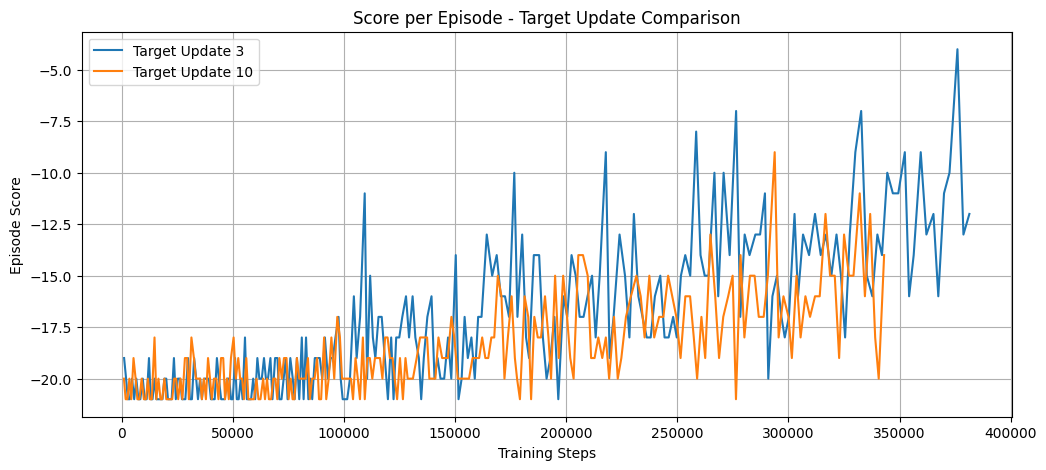

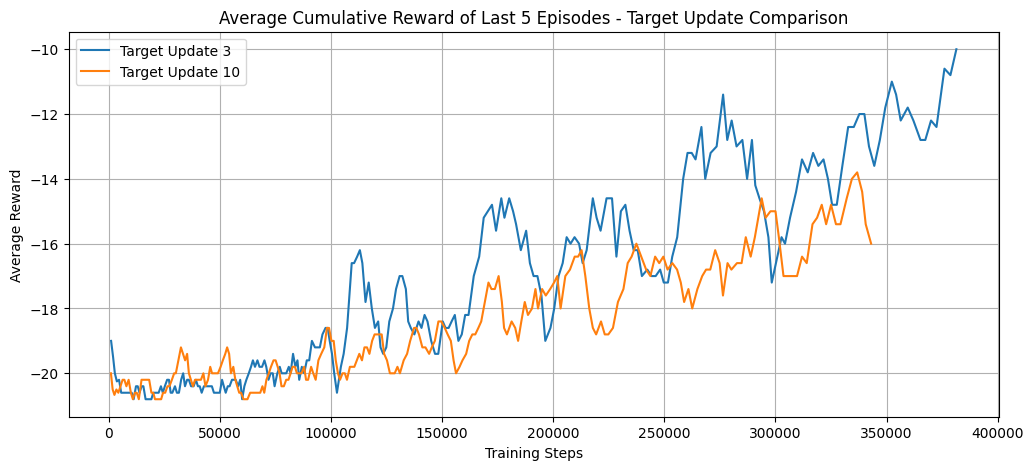

In [50]:
compare_runs(
    results_list=[results_tu3, results_tu10],
    metric_key="episode_scores",
    labels=["Target Update 3", "Target Update 10"],
    title="Score per Episode - Target Update Comparison",
    ylabel="Episode Score"
)

compare_runs(
    results_list=[results_tu3, results_tu10],
    metric_key="last5_avg_rewards",
    labels=["Target Update 3", "Target Update 10"],
    title="Average Cumulative Reward of Last 5 Episodes - Target Update Comparison",
    ylabel="Average Reward"
)

#### **Interpretation**

Both target update settings show gradual improvement over training, but updating the target network every 3 episodes performs better overall than updating every 10 episodes.

From the score per episode plot, the 3-episode update setting reaches higher peak scores and shows stronger late-stage improvement. The 10-episode setting also improves, but its scores remain generally lower and more conservative.

From the average cumulative reward of the last 5 episodes plot, the difference is clearer. The 3-episode update schedule rises more steadily and reaches a better final average reward, while the 10-episode schedule improves more slowly and remains below it for most of the later training period.

Overall, this comparison suggests that more frequent target network updates helped learning under the current 250-episode budget. In this setup, updating every 3 episodes allowed the agent to adapt faster and achieve better performance than updating every 10 episodes.

### **Observations and Results**

**Default Training Run**

The initial 5-episode training run was intentionally used as a debug-stage experiment. Its purpose was to verify that the DQN pipeline executed correctly, including preprocessing, replay memory, model updates, and result plotting.

As expected, rewards remained strongly negative and no meaningful learning trend appeared within only 5 episodes. This confirmed that such a short run is useful for validation, but not for evaluating learning performance.

**Effect of Training Duration**

A duration comparison was then performed using 5, 250, and 500 episodes under the default configuration.

The comparison shows that:
- 5 episodes are insufficient for meaningful learning evaluation
- 250 episodes begin to show early signs of improvement, but remain unstable
- 500 episodes demonstrate clearer learning progress, with higher rewards and more consistent upward trends

This indicates that reinforcement learning performance becomes more observable only with sufficiently long training, and that longer runs are necessary to reveal meaningful learning behavior.

**Effect of Batch Size**

Batch sizes of 8 and 16 were compared using a training duration of 250 episodes.

The results indicate that:
- both configurations follow a similar overall learning trend
- batch size 8 shows slightly faster short-term improvements in some regions
- batch size 16 produces somewhat smoother but not clearly superior performance

Overall, the difference between the two batch sizes is modest, suggesting that batch size has a limited impact under the current training scale.

**Effect of Target Network Update Frequency**

Target update frequencies of every 3 episodes and every 10 episodes were compared using 250 episodes.

The observations show that:
- both configurations improve over time, but remain noisy
- updating every 3 episodes leads to faster improvement and better final rewards
- updating every 10 episodes results in slower and more conservative learning

This suggests that more frequent target network updates can improve learning speed and performance in this setup.

**Key Insight**

The notebook demonstrates several important reinforcement learning insights:

- very short runs are useful for debugging, but not evaluation  
- longer training durations are essential to observe learning trends  
- hyperparameter comparisons become meaningful only after sufficient training  
- training stability and performance are sensitive to design choices such as target update frequency  

Overall, the notebook progresses from implementation validation to structured experimentation, reflecting a more complete and realistic reinforcement learning workflow.

### **Limitations**

Although the notebook extends beyond the initial debug run, the overall training duration remains relatively limited for a complex Atari environment such as Pong.

Key limitations include:
- even 250 and 500 episodes are likely insufficient for full DQN convergence on Pong  
- observed improvements do not necessarily indicate stable or optimal performance  
- hyperparameter comparisons are indicative but not definitive  
- only a small subset of hyperparameters (batch size and target update frequency) was explored  
- computational constraints limited the scale and number of experiments  
- results are based on single training runs and may vary due to the stochastic nature of reinforcement learning  

As a result, the findings should be interpreted as structured experimental observations rather than conclusive evidence of optimal configurations.

### **Conclusion**

This notebook implemented a Deep Q-Network (DQN) for Atari Pong using key reinforcement learning components, including frame preprocessing, frame stacking, experience replay, a target network, epsilon-greedy exploration, and a convolutional neural network.

The work followed a structured experimental progression:
1. a short 5-episode debug run was used to validate the training pipeline  
2. longer runs of 250 and 500 episodes were conducted to examine the effect of training duration  
3. batch size and target network update frequency were then compared using a more meaningful training scale  

The results demonstrate that very short runs are not suitable for evaluating reinforcement learning performance, while longer runs reveal clearer learning trends. In particular, the 500-episode experiment showed noticeable improvement in rewards, indicating that the agent was beginning to learn, although full convergence was not achieved.

Hyperparameter experiments showed that batch size had a relatively modest impact under the current setup, while more frequent target network updates (every 3 episodes) led to faster and better learning compared to less frequent updates.

Overall, the notebook successfully implements a DQN-based approach and presents a coherent experimental analysis. It highlights the importance of training duration and controlled experimentation when interpreting reinforcement learning results. These findings also emphasize the challenges of training agents in complex environments like Pong within limited computational budgets.

### **Summary of Experiments**

| Experiment Group          | Configuration               | Training Length | Key Observation                                                                 | Conclusion                                                                 |
|--------------------------|-----------------------------|----------------|----------------------------------------------------------------------------------|---------------------------------------------------------------------------|
| **Duration Comparison**  | Default settings            | 5 episodes     | Rewards remain strongly negative with no learning trend                          | Useful for debugging, not for evaluation                                  |
|                          | Default settings            | 250 episodes   | Early signs of improvement but still noisy and unstable                          | Partial learning observed                                                  |
|                          | Default settings            | 500 episodes   | Clear improvement with higher rewards and more consistent trends                 | Strongest evidence of learning among tested runs                          |
| **Batch Size Comparison**| Batch Size = 8              | 250 episodes   | Slightly faster short-term improvements with higher variability                  | May adapt faster but less stable                                          |
|                          | Batch Size = 16             | 250 episodes   | Smoother learning curve with similar overall performance                         | No clear advantage over batch size 8                                      |
| **Target Update Comparison** | Update every 3 episodes | 250 episodes   | Faster improvement and better final rewards                                      | More frequent updates improve learning performance                        |
|                          | Update every 10 episodes    | 250 episodes   | Slower and more conservative improvement                                         | Less effective under current training duration                            |

---

### **Overall Takeaways**

- Training duration has the largest impact on observed performance  
- Clear learning behavior only becomes visible at longer durations (500 episodes)  
- Hyperparameter comparisons were conducted under controlled conditions (fixed 250 episodes) to isolate their effects  
- More frequent target network updates provided the most noticeable improvement  
- Results should be interpreted as indicative rather than definitive due to limited training scale